In [1]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bhggygyv
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification


100%|██████████| 435M/435M [00:06<00:00, 65.7MB/s]


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/content/tom-and-jerry-image-classification/challenges.csv')
df.head()

,folder,image_name
0,jerry,frame360.jpg
1,jerry,frame1794.jpg
2,jerry,frame1795.jpg
3,jerry,frame2231.jpg
4,jerry,frame2234.jpg


In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry",
    labels="inferred",
    label_mode="int",
    image_size=(128, 128), # Standardize image size for the model
    shuffle=True, # Shuffle the dataset before splitting
    batch_size=None # <--- IMPORTANT: Do not batch here initially
)

Found 5478 files belonging to 4 classes.


In [5]:
class_names = dataset.class_names
print(class_names)

['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']


Collected samples for plotting:
jerry: 4 samples
tom: 4 samples
tom_jerry_0: 4 samples
tom_jerry_1: 4 samples


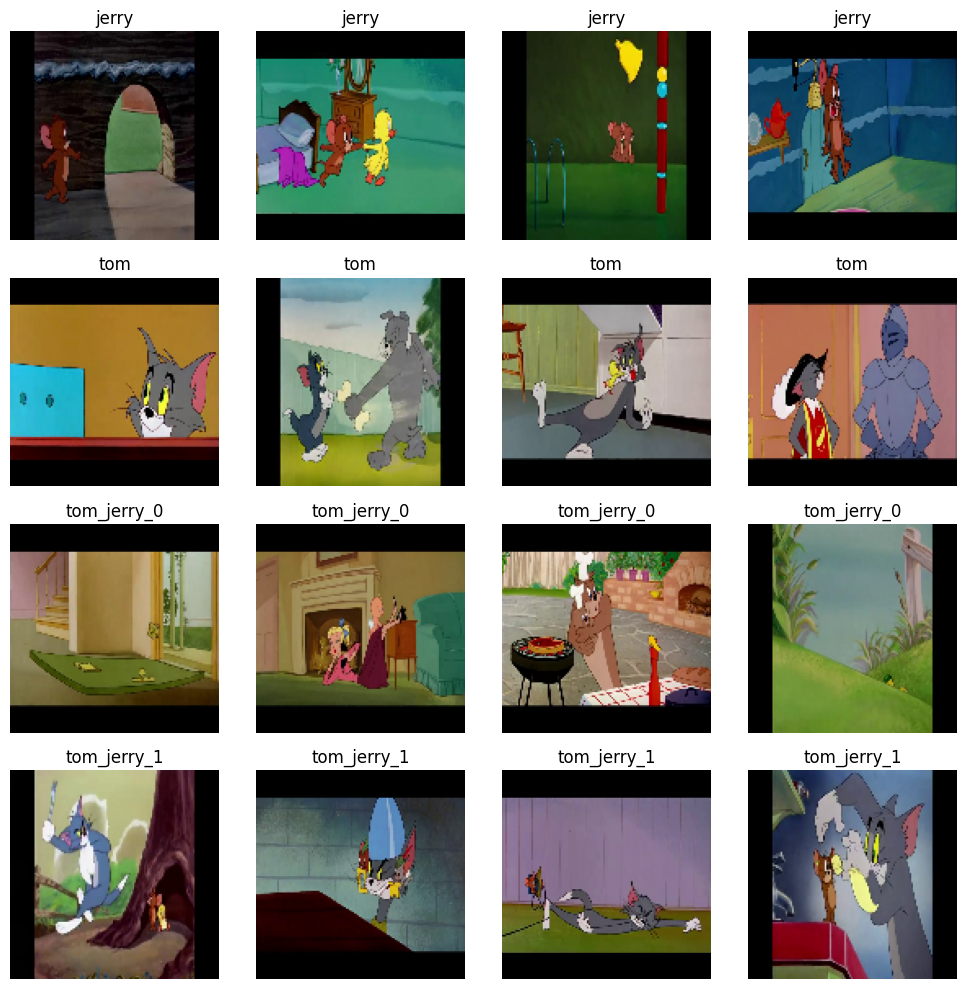

In [6]:
import random
import matplotlib.pyplot as plt

num_per_class = 4

# Initialize images_by_class and populate it
images_by_class = {i: [] for i in range(len(class_names))}

# Iterate through the dataset to collect samples for plotting
# We will iterate over the dataset until we have enough samples for each class
# or exhaust the dataset. 'dataset' is now unbatched.
print("Collecting sample images for visualization...")
for image, label_tensor in dataset:
    label_int = int(label_tensor.numpy())
    if len(images_by_class[label_int]) < num_per_class:
        images_by_class[label_int].append(image.numpy())

    # Check if we have collected enough samples for all classes
    all_classes_full = True
    for class_list in images_by_class.values():
        if len(class_list) < num_per_class:
            all_classes_full = False
            break
    if all_classes_full:
        break # Stop iterating once all classes have enough samples

print("Collected samples for plotting:")
for class_idx, samples in images_by_class.items():
    print(f"{class_names[class_idx]}: {len(samples)} samples")

plt.figure(figsize=(10,10))
plot_index = 1

for class_idx, class_name in enumerate(class_names):
    # pick 4 random images (or fewer if not enough were collected)
    selected_imgs = random.sample(images_by_class[class_idx], min(num_per_class, len(images_by_class[class_idx])))

    for img in selected_imgs:
        plt.subplot(len(class_names), num_per_class, plot_index)
        plt.imshow(img.astype("uint8"))
        plt.title(class_name)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

In [8]:
import collections

# Initialize a counter for each class
class_counts = collections.Counter()

# Iterate through the dataset to count samples for each class
# We need to re-create the original dataset to ensure we count all samples
original_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry",
    labels="inferred",
    label_mode="int",
    image_size=(128, 128),
    shuffle=False # No need to shuffle for counting
)

print("Counting samples per class...")
for images, labels in original_dataset:
    for label in labels:
        class_counts[int(label.numpy())] += 1

# Map numerical labels back to class names for better readability
category_samples = {}
for class_idx, count in class_counts.items():
    class_name = class_names[class_idx]
    category_samples[class_name] = count

print("\nNumber of samples per category:")
for class_name, count in category_samples.items():
    print(f"{class_name}: {count} samples")

Found 5478 files belonging to 4 classes.
Counting samples per class...

Number of samples per category:
jerry: 1240 samples
tom: 1930 samples
tom_jerry_0: 1528 samples
tom_jerry_1: 780 samples


### Step 1: Data Splitting and Preprocessing


In [9]:
import math

# Determine the total number of images in the dataset
# Using dataset.cardinality().numpy() is ideal if known, otherwise iterate (slower)
num_images = tf.data.experimental.cardinality(dataset).numpy()
# -2 means unknown cardinality, so we'll iterate
if num_images == -2:
    print("Cardinality unknown, iterating through dataset to count images...")
    num_images = 0
    for _ in dataset:
        num_images += 1
    print(f"Total images counted: {num_images}")

# Define the split ratios
train_split = 0.8
val_split = 0.1
test_split = 0.1

# Calculate the number of samples for each split
train_size = math.floor(num_images * train_split)
val_size = math.floor(num_images * val_split)
test_size = num_images - train_size - val_size # Assign remaining to test

print(f"Total images: {num_images}")
print(f"Train size: {train_size}")
print(f"Validation size: {val_size}")
print(f"Test size: {test_size}")

# Split the dataset
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size).take(test_size)


IMAGE_WIDTH, IMAGE_HEIGHT = 128, 128
NUM_CLASSES = len(class_names)
BATCH_SIZE = 32

# Function to normalize images and one-hot encode labels
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0 # Normalize to [0, 1]
    label = tf.one_hot(label, NUM_CLASSES)    # One-hot encode labels
    return image, label

# Apply preprocessing, batching, caching, and prefetching
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("\nDataset preparation complete. Ready for model building.")

Total images: 5478
Train size: 4382
Validation size: 547
Test size: 549

Dataset preparation complete. Ready for model building.


### Step 2: Build a ResNet Model using Transfer Learning



In [10]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models, optimizers

# Load the pre-trained ResNet50V2 model without its top classification layer
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3))

# Freeze the convolutional base to prevent its weights from being updated during training
base_model.trainable = False

# Create a new model on top of the pre-trained base
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Reduce spatial dimensions
    layers.Dense(128, activation='relu'), # Custom dense layer for feature learning
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(NUM_CLASSES, activation='softmax') # Output layer for our 4 classes
])

# Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()
print("\nResNet model with custom classification head built and compiled.")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,588 (90.90 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)


ResNet model with custom classification head built and compiled.


### Step 3: Train the Model


In [11]:
epochs = 20
print("Starting model training...")
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

print("\nModel training complete.")

Starting model training...
Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 274ms/step - accuracy: 0.4484 - loss: 1.5307 - val_accuracy: 0.6856 - val_loss: 0.8579
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6275 - loss: 0.9123 - val_accuracy: 0.7459 - val_loss: 0.6979
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7029 - loss: 0.7557 - val_accuracy: 0.7971 - val_loss: 0.6127
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7478 - loss: 0.6430 - val_accuracy: 0.8080 - val_loss: 0.5531
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7693 - loss: 0.5760 - val_accuracy: 0.8208 - val_loss: 0.5194
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7981 - loss: 0.4995 - val_accuracy: 0.8318 - val_loss: 0.4977
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8293 - loss: 0.4533 - val_accuracy: 0.8501 - val_loss: 0.4606
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8

Text(0.5, 1.0, 'Train\xa0-\xa0Accuracy')

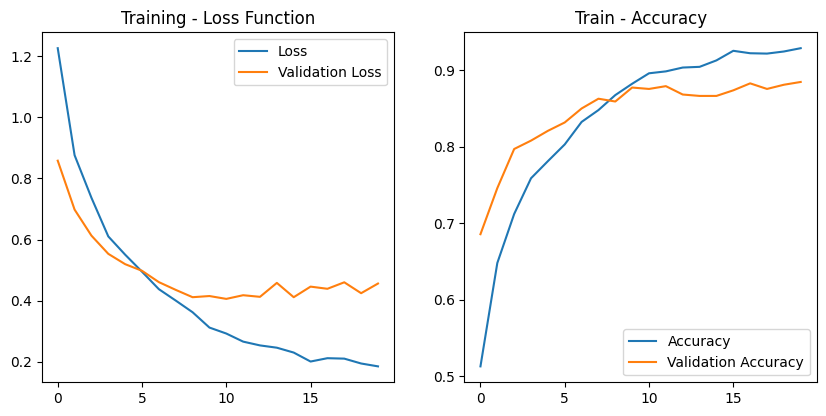

In [12]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy') # Changed 'acc' to 'accuracy'
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') # Changed 'val_acc' to 'val_accuracy'
plt.legend()
plt.title('Train - Accuracy')

In [13]:
model.save_weights("resnet_tomjerry.weights.h5")

In [14]:
model.save("resnet_tomjerry.keras")